# The learnable General Signature Kernel — recovering the order

Two of the six GSK columns **learn** their order-weighting $\varphi(k)$ from
labelled data instead of fixing it:

* **`sig-Wphi`** (truncated, *free weights*): $\varphi(0)=1$ pinned,
  $\varphi(1{:}N)=\mathrm{softplus}(\theta)\ge0$ — an **arbitrary** nonnegative,
  possibly **non-monotone** level profile.
* **`sig-PDEphi`** (untruncated, *dilation mixture*):
  $\varphi(k)=\sum_{i=1}^m w_i\lambda_i^{k}$ with $w=\mathrm{softmax}(\cdot)\ge0$,
  $\lambda_i\in(0,\lambda_{\max})$. By the **dilation identity** (Cass–Lyons–Xu),
  a geometric mixture of dilated signature kernels *is* an order-weighting — but
  a **completely monotone** (decaying) one.

Both are **two-phase**: `fit_phi(Xtr, ytr)` learns $\varphi$ by maximizing
centered kernel–target alignment (CKA) on the **training** set; the object is
then frozen and behaves as an ordinary precomputed PSD kernel ($\varphi\ge0\Rightarrow$
conic sum of PSD level kernels). Design: `docs/SIGNATURE_KERNELS.md` §0.3–0.7.

**The question this notebook answers:** if a data-generating process plants its
class signal at a *known* signature order $k^\star$, does the learned
$\varphi(k)$ **peak at $k^\star$**? And what can each of the two learners
represent?

## Environment

In [1]:
import sys, pathlib
_nbdir = pathlib.Path.cwd()
_root = _nbdir.parent if (_nbdir / "_nbtools.py").exists() else _nbdir
_nbdir = _root / "notebooks"
for _p in (str(_nbdir), str(_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import matplotlib.pyplot as plt
import ksig
ksig.set_default_device("cpu")          # statistical demos run on CPU (small, reproducible)
import _nbtools as nb
import _gsk_demo as g
%matplotlib inline

ENV = nb.detect_env()
nb.print_env_banner(ENV)
print("GSK demo  | paths/DGP:", g.N_TRAIN, "| length:", g.L, "| channels:", g.D,
      "| truncation N:", g.N_LEVELS, "| fit steps:", g.FIT_STEPS)

[2026-06-11 23:54:23,145] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to xpu (auto detect)


icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
/usr/bin/ld: /tmp/siebenschuh/tmpxueo13xw/test.o: in function `main':
test.c:(.text+0x25): undefined reference to `io_pgetevents'
icx: error: linker command failed with exit code 1 (use -v to see invocation)


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/torch/xpu/__init__.py:60: UserWarning: XPU device count is zero! (Triggered internally at /lus/tegu/projects/datasets/software/wheelforge/repositories/pytorch_2p8_rel_07_18_2025/pytorch/c10/xpu/XPUFunctions.cpp:115.)
  return torch._C._xpu_getDeviceCount()


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-11 23:54:28,853] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


ksig backend : torch  |  device: cpu  |  SYCL: absent (no 2nd curve)  |  ksig unknown
GSK demo  | paths/DGP: 120 | length: 22 | channels: 2 | truncation N: 3 | fit steps: 200


## Planted-order data

`g.make_planted(level, n, seed)` confines the class signal to one signature
**level** and makes everything else class-independent:

* **level 1** — a class-dependent straight **drift** (net displacement, zero area);
* **level 2** — a class-**oriented** closed loop (signed area, zero displacement);
* **level 3** — a class-**time-reversed** figure-eight (zero area; energy in the
  odd $\ge$3 tail) over a class-independent micro-loop.

These are the level-localized primitives of the inductive-bias suite, retuned so
the matched order is unambiguous at truncation $N=3$.

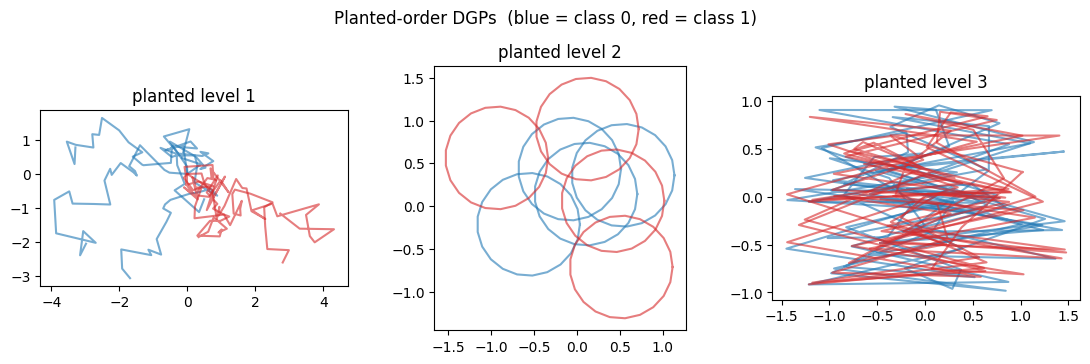

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for lvl, a in zip((1, 2, 3), ax):
    X, y = g.make_planted(lvl, 60, seed=lvl)
    for cls, c in zip((0, 1), ("tab:blue", "tab:red")):
        for i in np.where(y == cls)[0][:4]:
            a.plot(X[i, :, 0], X[i, :, 1], c=c, alpha=0.6)
    a.set_title(f"planted level {lvl}"); a.set_aspect("equal")
fig.suptitle("Planted-order DGPs  (blue = class 0, red = class 1)")
plt.tight_layout(); plt.show()

## Order recovery — does $\varphi$ peak at the planted level?

For each planted level $k^\star\in\{1,2,3\}$ we fit **`sig-Wphi`** (free weights,
$N=3$) on the train split and read off the learned $\varphi(1{:}N)$. The dashed
line marks $k^\star$; recovery means the **argmax lands on it**.

planted level 1:  phi = [1.    0.548 0.038 0.322]   ->  peak at level 1   (recovered)


planted level 2:  phi = [1.    0.698 2.553 0.033]   ->  peak at level 2   (recovered)


planted level 3:  phi = [1.    0.772 0.024 3.325]   ->  peak at level 3   (recovered)


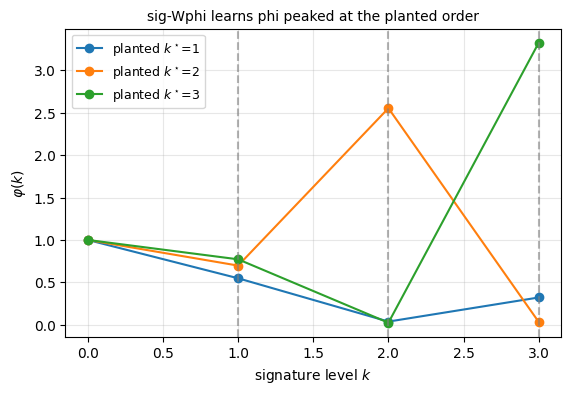

In [3]:
import torch
profiles, recovered = {}, {}
for lvl in (1, 2, 3):
    Xtr, ytr, _, _ = g.split(lambda n, s: g.make_planted(lvl, n, s), seed=lvl)
    bw = g.median_bw(Xtr)
    torch.manual_seed(0)
    k = g.gsk("free", g.N_LEVELS, bw=bw).fit_phi(Xtr, ytr, steps=g.FIT_STEPS)
    phi = np.asarray(k.phi_profile())
    profiles[f"planted $k^\\star$={lvl}"] = phi
    recovered[lvl] = 1 + int(np.argmax(phi[1:]))          # argmax over levels 1..N
    print(f"planted level {lvl}:  phi = {np.round(phi, 3)}   ->  peak at level {recovered[lvl]}"
          f"   {'(recovered)' if recovered[lvl] == lvl else '(MISS)'}")

g.plot_phi(profiles, planted={f"k{l}": l for l in (1, 2, 3)},
           title="sig-Wphi learns phi peaked at the planted order")
plt.show()

## What each learner can represent — free weights vs the dilation cone

`D_peak` plants the signal at **level 2** with **noise at levels 1 and 3**, so
the ideal $\varphi$ is a **non-monotone peak** (suppress 1 and 3, keep 2). We fit
both learnable kernels and compare their learned $\varphi$:

* **`sig-Wphi`** (free weights) *can* peak — $\varphi(2)>\varphi(1)$.
* **`sig-PDEphi`** is a sum of $\lambda_i^k$ with $\lambda_i,w_i\ge0$, i.e. a
  **completely monotone** (Stieltjes) sequence — it is **structurally forbidden**
  from peaking and must be non-increasing.

This is the theory linchpin behind `D_peak`'s CKA gap, checked here directly on
the **coefficients** (no data-calibration dependence).

sig-Wphi    phi = [1.    0.023 3.065 7.111]   peak above level 1? True
sig-PDEphi  phi = [1.    0.455 0.208 0.095]   monotone non-increasing? True


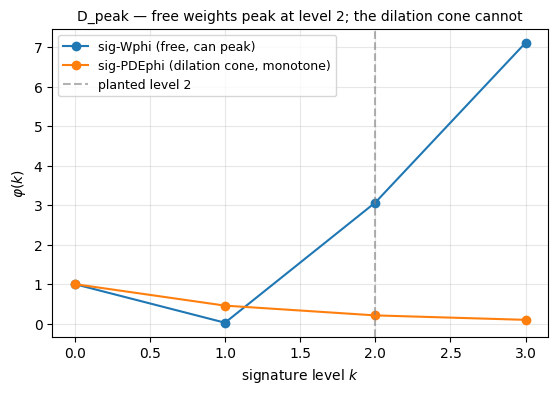

In [4]:
import torch
Xtr, ytr, _, _ = g.split(g.make_peak, seed=list(g.DATASETS).index("D_peak"))
bw = g.median_bw(Xtr)
torch.manual_seed(0)
wphi = g.gsk("free", g.N_LEVELS, bw=bw).fit_phi(Xtr, ytr, steps=g.FIT_STEPS)
torch.manual_seed(0)
pdephi = g.gsk("dilation", None, bw=bw).fit_phi(Xtr, ytr, steps=g.FIT_STEPS)

w = np.asarray(wphi.phi_profile(g.N_LEVELS))
p = np.asarray(pdephi.phi_profile(g.N_LEVELS))
print(f"sig-Wphi    phi = {np.round(w, 3)}   peak above level 1? {bool(w[2] > w[1])}")
print(f"sig-PDEphi  phi = {np.round(p, 3)}   monotone non-increasing? {bool(np.all(np.diff(p) <= 1e-6))}")

g.plot_phi({"sig-Wphi (free, can peak)": w, "sig-PDEphi (dilation cone, monotone)": p},
           planted=2, title="D_peak — free weights peak at level 2; the dilation cone cannot")
plt.show()

## The payoff — learning $\varphi$ buys alignment on the matched data

Finally, the out-of-sample CKA of the two learners against the fixed-$\varphi$
baselines and an order-blind reference, on the DGPs each learner is built for:

* **`D_peak`** (non-monotone) — `sig-Wphi` should win outright.
* **`D_lowsig`** (tail noise) — `sig-PDEphi`'s soft-decay should beat uniform `sig-PDE`.
* **`D_scale`** (tail signal) — the clamp chain `sig-Wphi > sig-PDE > sig-PDEphi`.

[D_peak] sig-L1=+0.015  sig-TRUNC=+0.088  sig-PDE=+0.085  sig-Wphi=+0.182  sig-PDEphi=+0.047


[D_lowsig] sig-L1=-0.005  sig-TRUNC=+0.202  sig-PDE=+0.379  sig-Wphi=+0.219  sig-PDEphi=+0.433


[D_scale] sig-L1=+0.031  sig-TRUNC=+0.255  sig-PDE=+0.198  sig-Wphi=+0.800  sig-PDEphi=+0.082


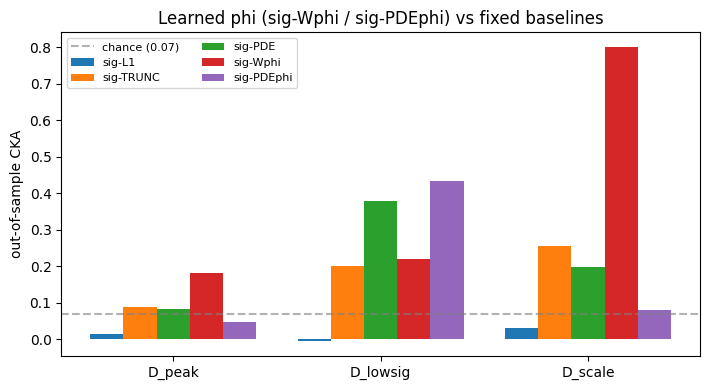

In [5]:
cols = ["sig-L1", "sig-TRUNC", "sig-PDE", "sig-Wphi", "sig-PDEphi"]
reg = {k: v for k, v in g.kernel_registry().items() if k in cols}
M = g.confusion_matrix(datasets=["D_peak", "D_lowsig", "D_scale"], kernels=reg)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
xpos = np.arange(len(M)); w = 0.16
for j, name in enumerate(cols):
    ax.bar(xpos + (j - 2) * w, [M[d][name] for d in M], w, label=name)
ax.axhline(g.CHANCE, ls="--", color="grey", alpha=0.6, label=f"chance ({g.CHANCE})")
ax.set_xticks(xpos); ax.set_xticklabels(list(M)); ax.set_ylabel("out-of-sample CKA")
ax.set_title("Learned phi (sig-Wphi / sig-PDEphi) vs fixed baselines")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## Takeaways

* **The learned $\varphi$ recovers the planted order.** On a signal confined to
  level $k^\star$, `sig-Wphi`'s free weights peak at $k^\star$ for $k^\star=1,2,3$.
* **Representation is a design choice.** Free weights (`sig-Wphi`) span arbitrary
  nonnegative — including non-monotone — profiles; the dilation mixture
  (`sig-PDEphi`) is **completely monotone** by construction, trading expressivity
  for an *untruncated* kernel and a soft, decaying tail.
* **Each wins where its bias matches the data** (`D_peak` → `sig-Wphi`,
  `D_lowsig` → `sig-PDEphi`), and the $\lambda_{\max}$ clamp caps the dilation
  cone away from tail-*amplifying* signals (`D_scale`).
* **PSD throughout** ($\varphi\ge0$), so a fitted kernel drops straight into any
  precomputed-kernel SVM/GP. See `07_general_signature_kernel.ipynb` for the full
  family map and `docs/SIGNATURE_KERNELS.md` for the derivations.